# ¿La cal agrícola emite CO₂ o lo captura?

**0,44 gigatoneladas de CO₂.** Es lo que podía capturar, en el mejor de los casos, toda la cal que se
echó a los cultivos de la cuenca del Misisipi entre 1900 y 2015. La contabilidad por defecto del IPCC
anota esa misma cifra, pero como CO₂ **emitido**.

¿Cuál de las dos cuentas se parece a lo que pasó? El río lleva la suya.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Suhrhoff et al. (2026), *Nature* — «Agricultural liming is a carbon sink in the Mississippi River Basin»
**DOI:** [10.1038/s41586-026-11040-2](https://doi.org/10.1038/s41586-026-11040-2)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-23-encalado-agricola-sumidero-carbono/notebook.ipynb)

**Video:** [Pendiente]

Los suelos de cultivo se acidifican: los fertilizantes nitrogenados, el estiércol y la lluvia ácida les
añaden ácido año tras año. Para contrarrestarlo se les echa cal — roca caliza o dolomita molida, es decir,
carbonato —, y a eso se le llama **encalado**. Sube el rendimiento de las cosechas, pero los inventarios de
gases de efecto invernadero lo anotan como una fuente de CO₂.

El equipo de Tim Jesper Suhrhoff reconstruyó un siglo de cal y de acidez en la cuenca del Misisipi, que
cubre el 41 % de la superficie de EE. UU. contiguo y cerca del 65 % de su área de cultivo, y lo comparó con
el bicarbonato que el río lleva al golfo de México. Lo que cambia la cuenta es contra qué se compara (el contrafactual): la pregunta no es «¿cal
o nada?», sino «¿acidez con cal o la misma acidez sin cal?». Los autores argumentan que quien empuja la
salida de CO₂ es el ácido, no la cal.

Tenemos 116 años (1900-2015) en medias de cuenca, y lo que simula un modelo que sigue cómo el agua arrastra y hace reaccionar lo que lleva disuelto en el suelo (SCEPTER, de
transporte reactivo) con dos supuestos sobre cuánta agua atraviesa el suelo: toda la lluvia (**P**) o la
lluvia menos lo que se evapora y transpiran las plantas (**P−ET**).

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FRACCION_ATMOSFERICA = 0.5   # fracción del carbono del exceso de bicarbonato que viene del aire (supuesto del paper)
ANIO_FINAL = 2015            # año hasta el que se acumula todo
FUENTE = ('Fuente: Suhrhoff et al. (2026), Nature | Datos: Source Data Fig. 2-3 (MOESM3/4) '
          'y Zenodo 10.5281/zenodo.21823981')
COLOR_DATOS = '#2563EB'      # río (medido)
COLOR_ALERTA = '#DC2626'     # contabilidad IPCC / emisión
COLOR_MODELO = '#059669'     # modelo SCEPTER
COLOR_REFERENCIA = '#D97706' # inventario EE. UU.
COLOR_GRIS = '#888888'       # potencial ideal
SLUG = '2026-09-23-encalado-agricola-sumidero-carbono'

import os
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo editorial CaM (local → fallback a GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# ── Carga (descarga desde el repo si no están en local) ──────
os.makedirs('datos', exist_ok=True)
ARCHIVOS = ['cdr_acumulado.csv', 'emisiones_co2_anuales.csv', 'balance_acido_alcalino_mrb.csv',
            'rio_bicarbonato.csv', 'escenarios_scepter_MtCO2.csv']
for f in ARCHIVOS:
    if not os.path.exists(f'datos/{f}'):
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{f}', f'datos/{f}')
cdr = pd.read_csv('datos/cdr_acumulado.csv')                 # GtCO2 acumulados desde 1900
emi = pd.read_csv('datos/emisiones_co2_anuales.csv')         # MtCO2/año, modelo con y sin cal + contabilidades
bal = pd.read_csv('datos/balance_acido_alcalino_mrb.csv')    # mol H+/ha/año, media de la cuenca
rio = pd.read_csv('datos/rio_bicarbonato.csv')               # bicarbonato del río Misisipi
esc = pd.read_csv('datos/escenarios_scepter_MtCO2.csv')      # 20 escenarios del modelo


def es(x, dec=2):
    # número en formato español: miles con punto, decimales con coma
    s = f'{x:_.{dec}f}'
    return s.replace('.', ',').replace('_', '.').replace('-', '−')


def pr(*a):
    print(*a)


from matplotlib.ticker import FuncFormatter
COMA = FuncFormatter(lambda v, _: es(v, 1))   # marcas de eje con coma decimal


# Del exceso de bicarbonato (TgC/año, frente a la media 1900-1934) a GtCO2 acumulados:
# TgC → GtC (/1000) → CO2 (×44,0095/12,011) → solo la fracción que vino del aire
C_A_CO2 = 44.0095 / 12.011
rio['cdr_GtCO2'] = rio['exceso_HCO3_TgC'].fillna(0).cumsum() / 1000 * C_A_CO2 * FRACCION_ATMOSFERICA
rio.loc[rio['anio'] < 1935, 'cdr_GtCO2'] = np.nan
rio['cdr_sd_GtCO2'] = cdr['rio_cdr_sd_GtCO2'] * FRACCION_ATMOSFERICA / 0.5

f_cdr = cdr[cdr['anio'] == ANIO_FINAL].iloc[0]
f_rio = rio[rio['anio'] == ANIO_FINAL].iloc[0]
pot, pot_sd = f_cdr['potencial_cdr_GtCO2'], f_cdr['potencial_cdr_sd_GtCO2']
r_cdr, r_sd = f_rio['cdr_GtCO2'], f_rio['cdr_sd_GtCO2']
pct, pct_sd = 100 * r_cdr / pot, 100 * r_sd / pot

pr(f'Años: {cdr["anio"].min()}-{cdr["anio"].max()} ({len(cdr)} filas por archivo)')
pr(f'Potencial ideal de captura acumulado a {ANIO_FINAL}: {es(pot)} ± {es(pot_sd)} GtCO₂')
pr(f'Captura según el río (fracción atmosférica {es(FRACCION_ATMOSFERICA, 1)}): {es(r_cdr)} ± {es(r_sd)} GtCO₂')
pr(f'Fracción realizada según el río: {es(pct, 1)} % ± {es(pct_sd, 1)} % '
   f'→ intervalo de ±1 desviación estándar: {es(pct - pct_sd, 0)}–{es(pct + pct_sd, 0)} %')
pr(f'Modelo SCEPTER: {es(f_cdr["scepter_PET_cdr_GtCO2"])} (P−ET) – {es(f_cdr["scepter_P_cdr_GtCO2"])} (P) GtCO₂ '
   f'= {es(100 * f_cdr["scepter_PET_cdr_GtCO2"] / pot, 0)}–{es(100 * f_cdr["scepter_P_cdr_GtCO2"] / pot, 0)} % del potencial')
pr(f'Contabilidad IPCC, emitido acumulado: {es(f_cdr["IPCC_emision_acum_GtCO2"])} GtCO₂ · '
   f'inventario EE. UU.: {es(f_cdr["EEUU_emision_acum_GtCO2"])} GtCO₂')

Años: 1900-2015 (116 filas por archivo)
Potencial ideal de captura acumulado a 2015: 0,44 ± 0,05 GtCO₂
Captura según el río (fracción atmosférica 0,5): 0,40 ± 0,09 GtCO₂
Fracción realizada según el río: 90,4 % ± 20,6 % → intervalo de ±1 desviación estándar: 70–111 %
Modelo SCEPTER: 0,22 (P−ET) – 0,37 (P) GtCO₂ = 49–83 % del potencial
Contabilidad IPCC, emitido acumulado: 0,44 GtCO₂ · inventario EE. UU.: 0,22 GtCO₂


Aquí está.

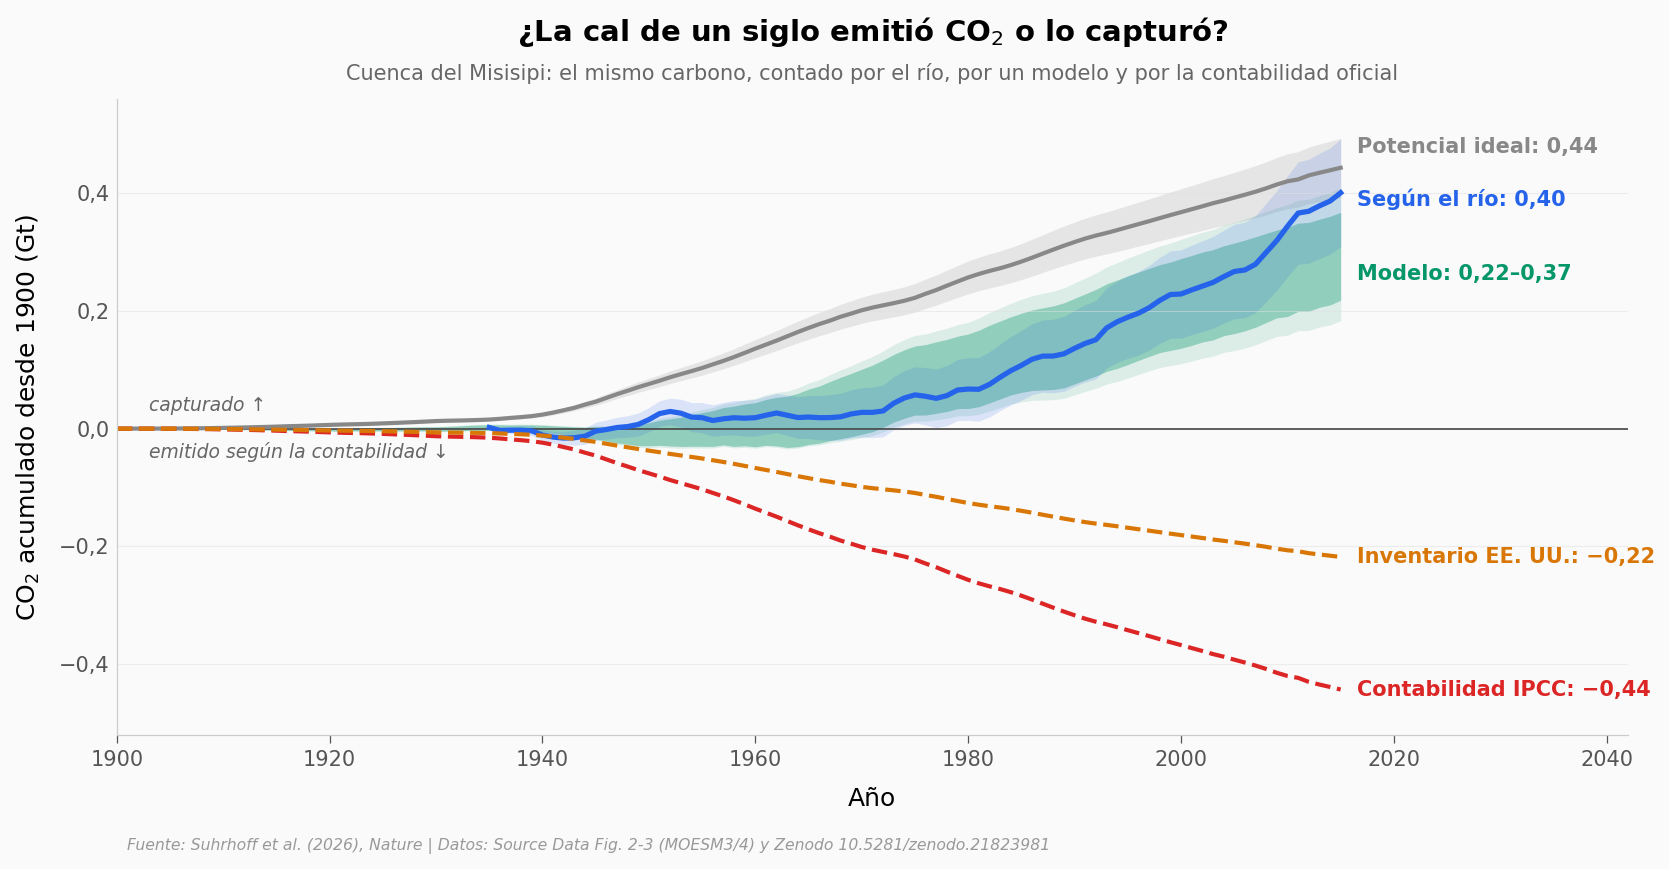

Desfase didáctico (A), mejor ajuste con 100 % realizado: 26 años (error cuadrático medio 0,028 GtCO₂)
  (B) acumulado 0,05 GtCO₂: potencial en 1946, río en 1974 → 28 años
  (B) acumulado 0,20 GtCO₂: potencial en 1970, río en 1996 → 27 años
  (B) acumulado 0,40 GtCO₂: potencial en 2006, río en 2015 → 8 años


In [2]:
c = cdr[cdr['anio'] <= ANIO_FINAL]
r = rio[(rio['anio'] <= ANIO_FINAL) & (rio['anio'] >= 1935)]
x = c['anio']

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.axhline(0, color='#444444', linewidth=0.8)

# Modelo: envolvente con incertidumbre de inputs (clara) y rango P−ET a P (oscura)
ax.fill_between(x, c['scepter_incert_min_GtCO2'], c['scepter_incert_max_GtCO2'],
                color=COLOR_MODELO, alpha=0.12, linewidth=0)
ax.fill_between(x, c['scepter_PET_cdr_GtCO2'], c['scepter_P_cdr_GtCO2'],
                color=COLOR_MODELO, alpha=0.35, linewidth=0)
# Potencial ideal ± 1 sd
ax.fill_between(x, c['potencial_cdr_GtCO2'] - c['potencial_cdr_sd_GtCO2'],
                c['potencial_cdr_GtCO2'] + c['potencial_cdr_sd_GtCO2'], color=COLOR_GRIS, alpha=0.18, linewidth=0)
ax.plot(x, c['potencial_cdr_GtCO2'], color=COLOR_GRIS, linewidth=2)
# Río ± 1 sd
ax.fill_between(r['anio'], r['cdr_GtCO2'] - r['cdr_sd_GtCO2'], r['cdr_GtCO2'] + r['cdr_sd_GtCO2'],
                color=COLOR_DATOS, alpha=0.15, linewidth=0)
ax.plot(r['anio'], r['cdr_GtCO2'], color=COLOR_DATOS, linewidth=2.5)
# Contabilidades: lo que anotan como emitido, dibujado hacia abajo
ax.plot(x, -c['IPCC_emision_acum_GtCO2'], color=COLOR_ALERTA, linewidth=2, linestyle='--')
ax.plot(x, -c['EEUU_emision_acum_GtCO2'], color=COLOR_REFERENCIA, linewidth=2, linestyle='--')

fin = c.iloc[-1]
xt = ANIO_FINAL + 1.5
ax.text(xt, fin['potencial_cdr_GtCO2'] + 0.035, f'Potencial ideal: {es(fin["potencial_cdr_GtCO2"])}',
        color=COLOR_GRIS, fontsize=10, fontweight='bold', va='center')
ax.text(xt, r['cdr_GtCO2'].iloc[-1] - 0.01, f'Según el río: {es(r["cdr_GtCO2"].iloc[-1])}',
        color=COLOR_DATOS, fontsize=10, fontweight='bold', va='center')
ax.text(xt, (fin['scepter_P_cdr_GtCO2'] + fin['scepter_PET_cdr_GtCO2']) / 2 - 0.03,
        f'Modelo: {es(fin["scepter_PET_cdr_GtCO2"])}–{es(fin["scepter_P_cdr_GtCO2"])}',
        color=COLOR_MODELO, fontsize=10, fontweight='bold', va='center')
ax.text(xt, -fin['EEUU_emision_acum_GtCO2'], f'Inventario EE. UU.: −{es(fin["EEUU_emision_acum_GtCO2"])}',
        color=COLOR_REFERENCIA, fontsize=10, fontweight='bold', va='center')
ax.text(xt, -fin['IPCC_emision_acum_GtCO2'], f'Contabilidad IPCC: −{es(fin["IPCC_emision_acum_GtCO2"])}',
        color=COLOR_ALERTA, fontsize=10, fontweight='bold', va='center')
ax.text(1903, 0.03, 'capturado ↑', color='#666666', fontsize=9, style='italic')
ax.text(1903, -0.05, 'emitido según la contabilidad ↓', color='#666666', fontsize=9, style='italic')

ax.set_xlim(1900, ANIO_FINAL + 27)
ax.set_ylim(-0.52, 0.56)
ax.yaxis.set_major_formatter(COMA)
ax.set_xlabel('Año')
ax.set_ylabel('CO$_2$ acumulado desde 1900 (Gt)')
ax.set_title('¿La cal de un siglo emitió CO$_2$ o lo capturó?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cuenca del Misisipi: el mismo carbono, contado por el río, por un modelo y por la contabilidad oficial',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/grafica_hero.png', dpi=200, bbox_inches='tight')
plt.show()

# Desfase entre la cal y el río — MÉTRICA DIDÁCTICA, NO ESTÁNDAR: el paper no da un número,
# solo «del orden de décadas». (A) desplazamos la curva del potencial L años y buscamos el L que
# mejor calza con el río 1935-ANIO_FINAL suponiendo que se realiza el 100 %; (B) año en que cada
# curva alcanza el mismo acumulado.
obs = r.set_index('anio')['cdr_GtCO2']
pot_s = cdr.set_index('anio')['potencial_cdr_GtCO2']
rmse = {L: np.sqrt(np.mean((obs.values - pot_s.reindex(obs.index - L).values) ** 2)) for L in range(0, 41)}
L_mejor = min(rmse, key=rmse.get)
pr(f'Desfase didáctico (A), mejor ajuste con 100 % realizado: {L_mejor} años (error cuadrático medio {es(rmse[L_mejor], 3)} GtCO₂)')
for nivel in [0.05, 0.20, 0.40]:
    a_pot = np.interp(nivel, pot_s.values, pot_s.index)
    a_rio = np.interp(nivel, obs.values, obs.index)
    pr(f'  (B) acumulado {es(nivel)} GtCO₂: potencial en {a_pot:.0f}, río en {a_rio:.0f} → {es(a_rio - a_pot, 0)} años')

Para 2015, el río acumula **0,40 GtCO₂** de captura (± 0,09). Los registros del río sugieren que se
realizó cerca del **90 %** del potencial ideal, con un margen de ± 21 %. Ese margen es ancho: con una
desviación estándar el intervalo va de 70 a 111 %, así que el río no descarta que se haya realizado todo.

El modelo es más conservador: entre 0,22 (P−ET) y 0,37 GtCO₂ (P), es decir, entre el 49 y el 83 % del
potencial. Son dos cuentas independientes — una sacada de las mediciones del río, otra simulada — y coinciden en el signo:
evaluado contra la misma acidez sin cal y en escalas de décadas a un siglo, el encalado funciona como sumidero neto en esta cuenca.

La curva del río va por detrás de la del potencial. La cal no llega al río al día siguiente: primero se
queda retenida en el suelo (intercambio de cationes) y luego viaja con el agua. El paper habla de un
desfase «del orden de décadas»; nuestro ajuste didáctico da unos 26 años, pero el cruce por niveles se
acorta de 28 años al principio a 8 años en el último nivel, que el río alcanza justo en 2015 (un solo año, al borde del registro): el desfase no parece un número fijo.

Mientras tanto, la contabilidad por defecto del IPCC anota **0,44 GtCO₂ emitidos**: el mismo número que el
potencial, con el signo opuesto. El inventario de EE. UU. anota 0,22.

⚠️ Para pasar del bicarbonato del río a CO₂, el paper supone que la mitad del carbono del exceso viene de la
atmósfera. Y atribuir ese exceso a la cal es una inferencia sobre una línea base anterior a 1935, no una
medición directa.

El acumulado esconde la historia año a año. El modelo simula dos cuencas gemelas: una recibe la acidez
real y la cal real; la otra, la misma acidez y nada de cal. Restarlas dice cuándo la cal ahorra CO₂ y
cuándo lo añade.

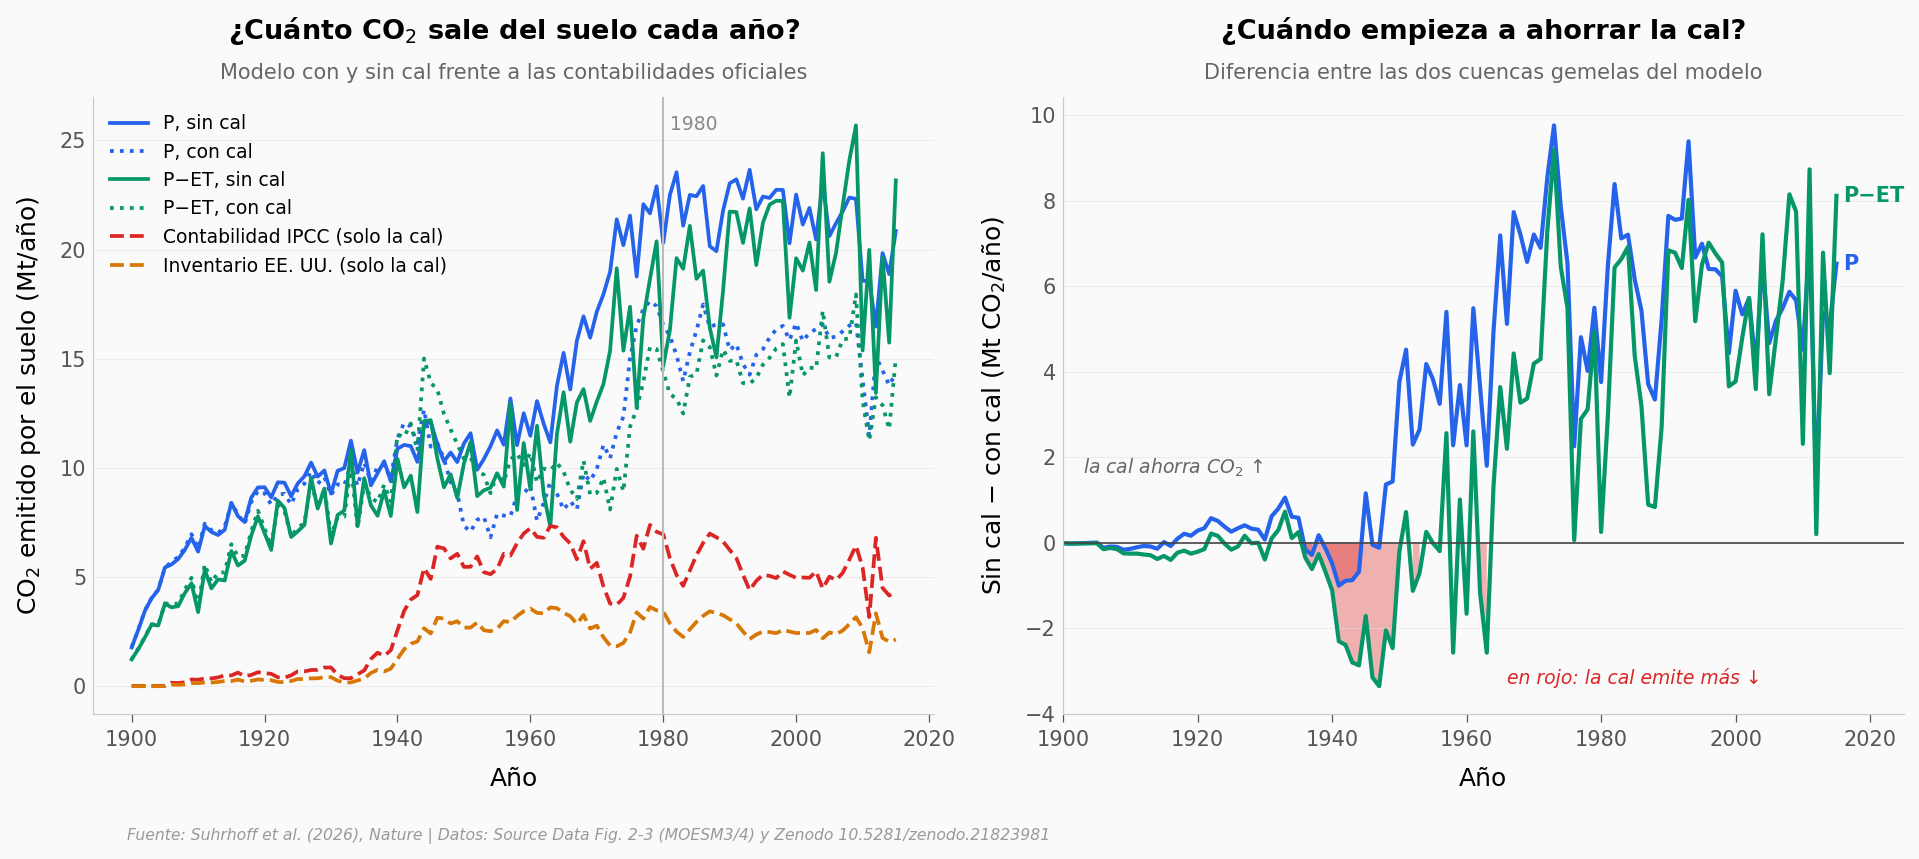

P: la cal emite más que sin cal en 10 años desde 1935; máximo 1,0 MtCO₂ de más en 1941
   el saldo acumulado no vuelve a ser negativo después de 1935
P−ET: la cal emite más que sin cal en 23 años desde 1935; máximo 3,4 MtCO₂ de más en 1947
   saldo acumulado negativo hasta 1971 (fondo −0,032 GtCO₂ en 1963)
1980 (MtCO₂/año): sin cal 14,7 (P−ET) – 20,3 (P) · con cal 14,4 (P−ET) – 16,6 (P) · IPCC 7,0 · EE. UU. 3,4


In [3]:
e = emi[emi['anio'] <= ANIO_FINAL]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

series = [('P_solo_acidez_MtCO2', 'P, sin cal', COLOR_DATOS, '-'),
          ('P_acidez_mas_cal_MtCO2', 'P, con cal', COLOR_DATOS, ':'),
          ('PET_solo_acidez_MtCO2', 'P−ET, sin cal', COLOR_MODELO, '-'),
          ('PET_acidez_mas_cal_MtCO2', 'P−ET, con cal', COLOR_MODELO, ':'),
          ('IPCC_cal_MtCO2', 'Contabilidad IPCC (solo la cal)', COLOR_ALERTA, '--'),
          ('EEUU_cal_MtCO2', 'Inventario EE. UU. (solo la cal)', COLOR_REFERENCIA, '--')]
for col, nombre, color, ls in series:
    ax1.plot(e['anio'], e[col], color=color, linestyle=ls, linewidth=1.8, label=nombre)
ax1.axvline(1980, color='#BBBBBB', linewidth=1)
ax1.text(1981, ax1.get_ylim()[1] * 0.97, '1980', color='#888888', fontsize=9, va='top')
ax1.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax1.set_xlabel('Año')
ax1.set_ylabel('CO$_2$ emitido por el suelo (Mt/año)')
ax1.set_title('¿Cuánto CO$_2$ sale del suelo cada año?', fontsize=13, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Modelo con y sin cal frente a las contabilidades oficiales', transform=ax1.transAxes,
         fontsize=10, color='#666666', ha='center')

for pre, nombre, color in [('P', 'P', COLOR_DATOS), ('PET', 'P−ET', COLOR_MODELO)]:
    d = e[f'{pre}_solo_acidez_MtCO2'] - e[f'{pre}_acidez_mas_cal_MtCO2']
    ax2.plot(e['anio'], d, color=color, linewidth=2)
    # antes de 1917 la cal es casi nula y las diferencias minúsculas son ruido numérico: no se sombrean
    ax2.fill_between(e['anio'], d, 0, where=(d < 0) & (e['anio'] >= 1930), color=COLOR_ALERTA, alpha=0.35, linewidth=0)
    ax2.text(ANIO_FINAL + 1, d.iloc[-1], nombre, color=color, fontsize=10, fontweight='bold', va='center')
ax2.axhline(0, color='#444444', linewidth=0.8)
ax2.text(1903, 1.6, 'la cal ahorra CO$_2$ ↑', color='#666666', fontsize=9, style='italic')
ax2.text(1966, -3.3, 'en rojo: la cal emite más ↓', color=COLOR_ALERTA, fontsize=9, style='italic')
ax2.set_xlim(1900, ANIO_FINAL + 10)
ax2.set_xlabel('Año')
ax2.set_ylabel('Sin cal − con cal (Mt CO$_2$/año)')
ax2.set_title('¿Cuándo empieza a ahorrar la cal?', fontsize=13, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'Diferencia entre las dos cuencas gemelas del modelo', transform=ax2.transAxes,
         fontsize=10, color='#666666', ha='center')
plt.tight_layout()
fig.text(0.07, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/emisiones_anuales.png', dpi=200, bbox_inches='tight')
plt.show()

for pre, nombre in [('P', 'P'), ('PET', 'P−ET')]:
    d = (emi[f'{pre}_solo_acidez_MtCO2'] - emi[f'{pre}_acidez_mas_cal_MtCO2']).values
    anios = emi['anio'].values
    m = anios >= 1935
    i = np.argmin(np.where(m, d, np.inf))
    acum = np.cumsum(d) / 1000
    neg = anios[(acum < 0) & (anios >= 1935)]
    pr(f'{nombre}: la cal emite más que sin cal en {int((d[m] < 0).sum())} años desde 1935; '
       f'máximo {es(-d[i], 1)} MtCO₂ de más en {anios[i]}')
    if len(neg):
        pr(f'   saldo acumulado negativo hasta {neg.max()} (fondo {es(acum.min(), 3)} GtCO₂ en {anios[np.argmin(acum)]})')
    else:
        pr('   el saldo acumulado no vuelve a ser negativo después de 1935')
f80 = emi[emi['anio'] == 1980].iloc[0]
pr('1980 (MtCO₂/año): sin cal ' + es(f80['PET_solo_acidez_MtCO2'], 1) + ' (P−ET) – ' + es(f80['P_solo_acidez_MtCO2'], 1)
   + ' (P) · con cal ' + es(f80['PET_acidez_mas_cal_MtCO2'], 1) + ' (P−ET) – ' + es(f80['P_acidez_mas_cal_MtCO2'], 1)
   + ' (P) · IPCC ' + es(f80['IPCC_cal_MtCO2'], 1) + ' · EE. UU. ' + es(f80['EEUU_cal_MtCO2'], 1))

En P−ET, la cal emite **más** que la cuenca sin cal sobre todo entre 1936 y 1950, con años sueltos hasta
1963 (máximo: 3,4 MtCO₂ de más en 1947). Es el pulso inicial: según el modelo, al principio la cal gasta su
carbonato en neutralizar la acidez que el suelo ya tenía acumulada. El saldo acumulado de P−ET se queda en
negativo hasta 1971. En P el pulso es más pequeño (máximo 1,0 en 1941) y, después de 1935, el saldo acumulado no vuelve a ser
negativo.

En 1980, la cuenca sin cal emite entre 14,7 (P−ET) y 20,3 MtCO₂ al año (P); con cal, entre 14,4 y 16,6. Las
dos contabilidades oficiales (IPCC: 7,0; EE. UU.: 3,4) quedan por debajo de los cuatro escenarios, porque
solo cuentan el carbono de la cal: el CO₂ que libera el ácido no aparece en su cuenta.

¿De dónde sale tanto ácido? Seis fuentes, sumadas en la media de la cuenca, frente a la cal que se echó.

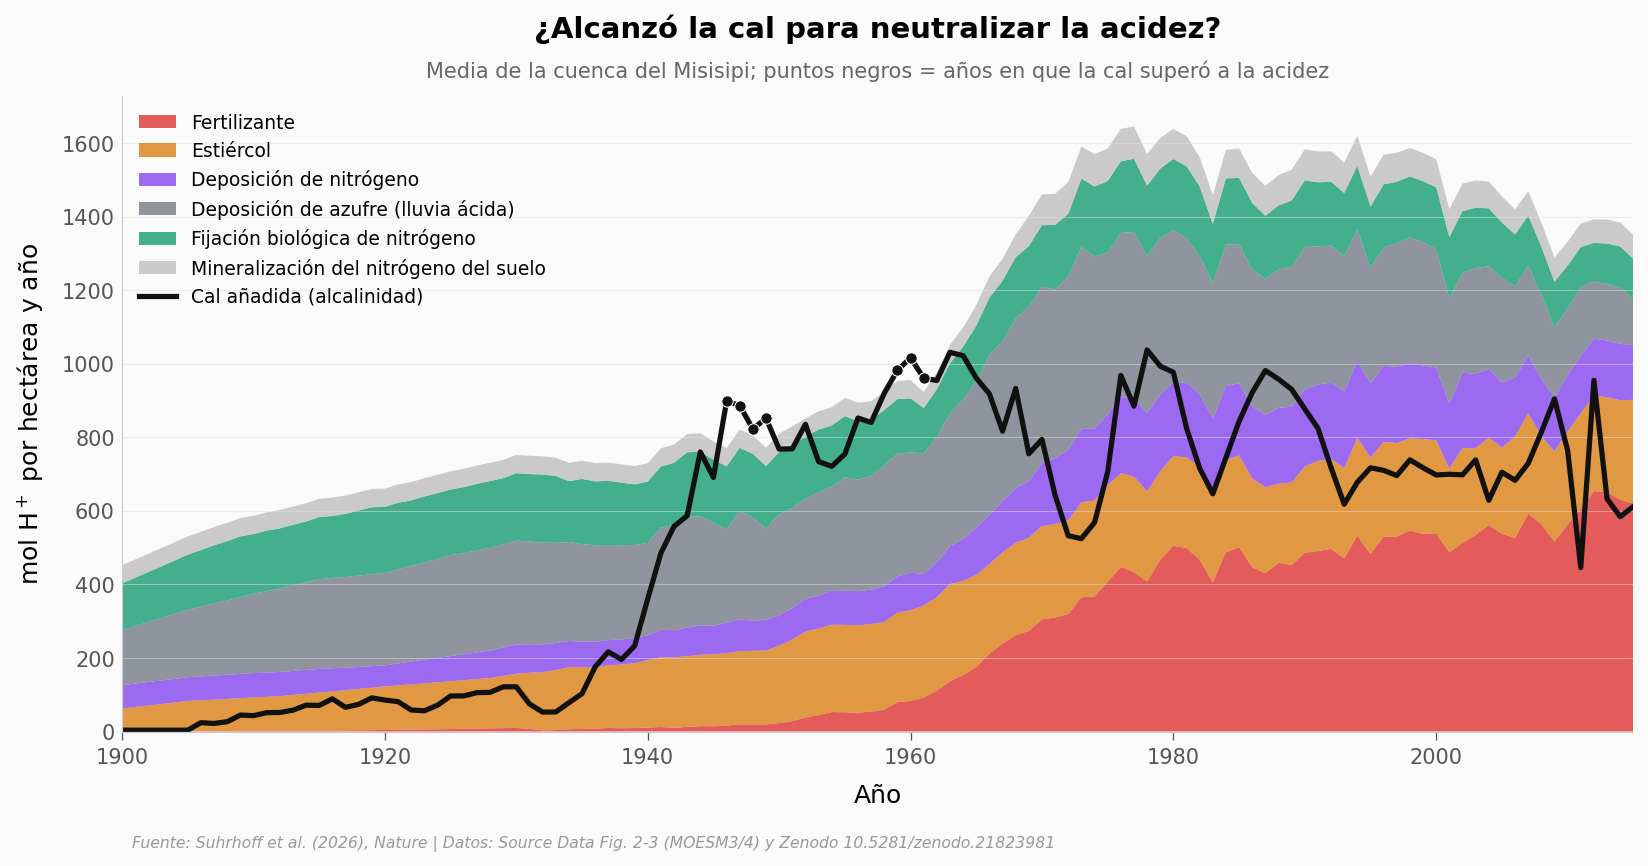

Acidez total: 452 en 1900 → máximo 1.645 en 1977; desde 1970 mediana 1.523 (rango intercuartílico 1.459–1.581) mol H⁺/ha/año
Años en que la cal superó a la acidez: 7 de 116 → [1946, 1947, 1948, 1949, 1959, 1960, 1961]
Fertilizante: 30,8 % de la acidez en 1980, 45,9 % en 2015
Deposición de azufre: máximo 495 en 1973 → 123 en 2015
Acidez sin neutralizar acumulada a 2015: 19,8 Tmol = 49,6 % de toda la acidez añadida desde 1900


In [4]:
b = bal[bal['anio'] <= ANIO_FINAL]
fuentes = [('fertilizante_molH_ha', 'Fertilizante', '#DC2626'),
           ('estiercol_molH_ha', 'Estiércol', '#D97706'),
           ('deposicion_N_molH_ha', 'Deposición de nitrógeno', '#7C3AED'),
           ('deposicion_S_molH_ha', 'Deposición de azufre (lluvia ácida)', '#6B7280'),
           ('fijacion_biologica_N_molH_ha', 'Fijación biológica de nitrógeno', '#059669'),
           ('mineralizacion_N_suelo_molH_ha', 'Mineralización del nitrógeno del suelo', '#BBBBBB')]
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.stackplot(b['anio'], *[b[c] for c, _, _ in fuentes], labels=[n for _, n, _ in fuentes],
             colors=[c for _, _, c in fuentes], alpha=0.75)
ax.plot(b['anio'], b['cal_alcalinidad_mol_ha'], color='#111111', linewidth=2.5, label='Cal añadida (alcalinidad)')
sup = b[b['cal_alcalinidad_mol_ha'] > b['acidez_total_molH_ha']]
ax.scatter(sup['anio'], sup['cal_alcalinidad_mol_ha'], color='#111111', s=30, zorder=5,
           edgecolors='white', linewidths=0.5)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.set_xlim(1900, ANIO_FINAL)
ax.set_xlabel('Año')
ax.set_ylabel('mol H$^+$ por hectárea y año')
ax.set_title('¿Alcanzó la cal para neutralizar la acidez?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Media de la cuenca del Misisipi; puntos negros = años en que la cal superó a la acidez',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/balance_acidez_cal.png', dpi=200, bbox_inches='tight')
plt.show()

post = b[b['anio'] >= 1970]['acidez_total_molH_ha']
imax = b['acidez_total_molH_ha'].idxmax()
f15 = b[b['anio'] == ANIO_FINAL].iloc[0]
f80 = b[b['anio'] == 1980].iloc[0]
pr(f'Acidez total: {es(b["acidez_total_molH_ha"].iloc[0], 0)} en 1900 → máximo {es(b.loc[imax, "acidez_total_molH_ha"], 0)} '
   f'en {b.loc[imax, "anio"]}; desde 1970 mediana {es(post.median(), 0)} '
   f'(rango intercuartílico {es(post.quantile(0.25), 0)}–{es(post.quantile(0.75), 0)}) mol H⁺/ha/año')
pr(f'Años en que la cal superó a la acidez: {len(sup)} de {len(b)} → {list(sup["anio"])}')
pr(f'Fertilizante: {es(100 * f80["fertilizante_molH_ha"] / f80["acidez_total_molH_ha"], 1)} % de la acidez en 1980, '
   f'{es(100 * f15["fertilizante_molH_ha"] / f15["acidez_total_molH_ha"], 1)} % en {ANIO_FINAL}')
iS = b['deposicion_S_molH_ha'].idxmax()
pr(f'Deposición de azufre: máximo {es(b.loc[iS, "deposicion_S_molH_ha"], 0)} en {b.loc[iS, "anio"]} → '
   f'{es(f15["deposicion_S_molH_ha"], 0)} en {ANIO_FINAL}')
pr(f'Acidez sin neutralizar acumulada a {ANIO_FINAL}: {es(f15["exceso_acidez_acumulado_Tmol"], 1)} Tmol = '
   f'{es(100 * (1 - f15["fraccion_acidez_neutralizada_acum"]), 1)} % de toda la acidez añadida desde 1900')

La acidez pasó de 452 mol H⁺ por hectárea y año en 1900 a un máximo de 1.645 en 1977, y desde 1970 se
mantiene alta y estable (mediana 1.523; la mitad central de los años, entre 1.459 y 1.581). Al final del registro, el fertilizante es el mayor aporte: 46 % en
2015, frente al 31 % de 1980. La lluvia ácida bajó: la deposición de azufre cayó de 495 en 1973 a 123 en 2015.

La cal superó a la acidez en solo 7 de 116 años (1946-1949 y 1959-1961). Para 2015 quedaban 19,8 billones
de moles (Tmol) de acidez sin neutralizar: la mitad de todo el ácido añadido desde 1900. Por eso el
contrafactual importa: ese ácido libera CO₂ con cal o sin ella.

⚠️ Es una media de cuenca. Según el paper, el exceso de acidez se concentra en tierras que reciben poca cal
(buena parte del oeste de la cuenca), mientras que en el cinturón del maíz la cal compensó o superó a la
acidez. Nuestros datos no muestran esa diferencia espacial.

¿Y el río?

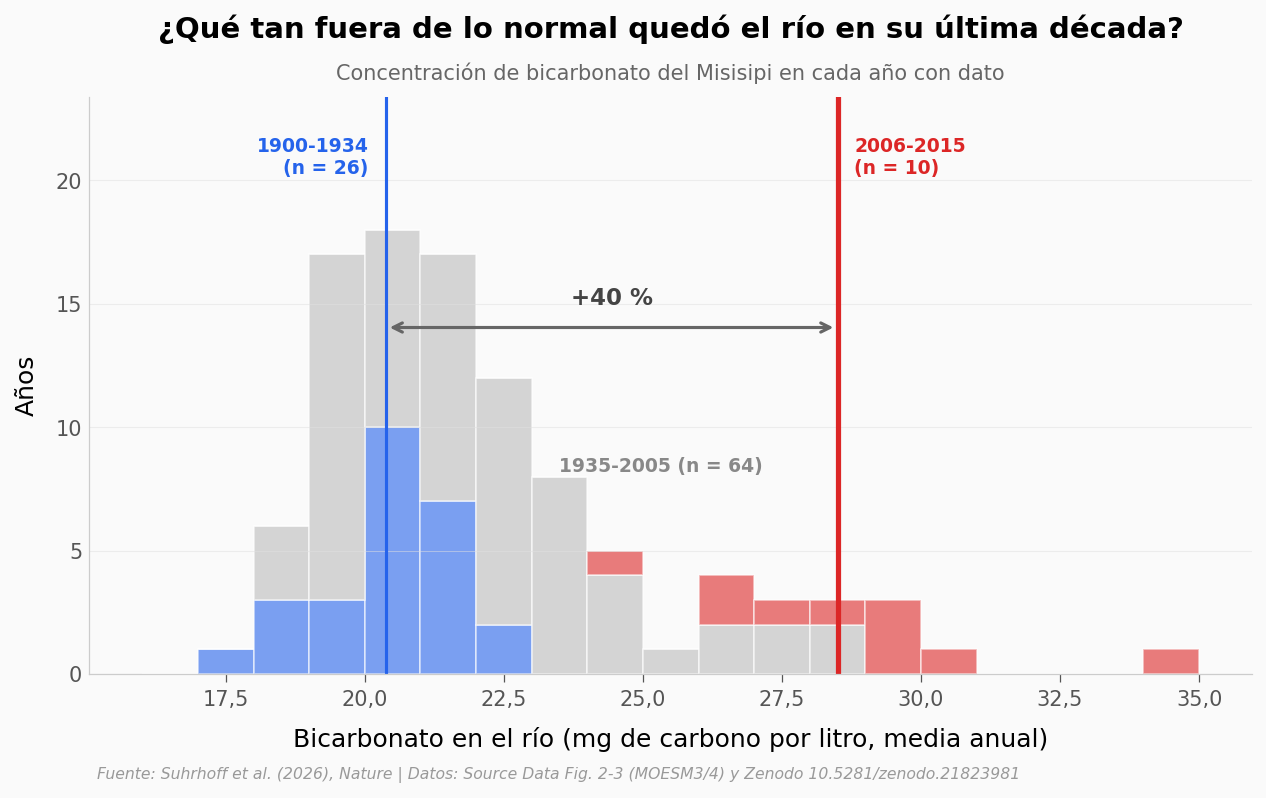

Años con dato: 100 de 116 (faltan 16)
1900-1934: media 20,4 mgC/L (desv. est. 1,2, máximo 22,4)
2006-2015: media 28,5 mgC/L; 10 de 10 años por encima del máximo de 1900-1934
Flujo (la métrica del paper): 10,2 TgC/año en 1900-1934 → 17,5 en 2006-2015 · caudal 504 → 614 km³/año


In [5]:
conc = rio.dropna(subset=['HCO3_mgC_L'])
base = conc[conc['anio'] < 1935]['HCO3_mgC_L']
medio = conc[(conc['anio'] >= 1935) & (conc['anio'] < 2006)]['HCO3_mgC_L']
reciente = conc[(conc['anio'] >= 2006) & (conc['anio'] <= ANIO_FINAL)]['HCO3_mgC_L']

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(16, 36, 1)
n, _, _ = ax.hist([base, medio, reciente], bins=bins, stacked=True,
                  color=[COLOR_DATOS, '#BBBBBB', COLOR_ALERTA], alpha=0.6, edgecolor='white', linewidth=0.8)
y_max = n[-1].max() * 1.3
ax.set_ylim(0, y_max)
ax.axvline(base.mean(), color=COLOR_DATOS, linewidth=1.5)
ax.axvline(reciente.mean(), color=COLOR_ALERTA, linewidth=2.5)
ax.annotate('', xy=(reciente.mean(), y_max * 0.6), xytext=(base.mean(), y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((base.mean() + reciente.mean()) / 2, y_max * 0.64,
        f'+{es(100 * (reciente.mean() / base.mean() - 1), 0)} %', ha='center', fontsize=11, fontweight='bold', color='#444444')
ax.text(base.mean() - 0.3, y_max * 0.93, f'1900-1934\n(n = {len(base)})', color=COLOR_DATOS,
        fontsize=9, fontweight='bold', ha='right', va='top')
ax.text(reciente.mean() + 0.3, y_max * 0.93, f'2006-{ANIO_FINAL}\n(n = {len(reciente)})', color=COLOR_ALERTA,
        fontsize=9, fontweight='bold', ha='left', va='top')
ax.text(23.5, y_max * 0.35, f'1935-2005 (n = {len(medio)})', color='#888888', fontsize=9, fontweight='bold')
ax.xaxis.set_major_formatter(COMA)
ax.set_xlabel('Bicarbonato en el río (mg de carbono por litro, media anual)')
ax.set_ylabel('Años')
ax.set_title('¿Qué tan fuera de lo normal quedó el río en su última década?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Concentración de bicarbonato del Misisipi en cada año con dato', transform=ax.transAxes,
        fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_bicarbonato.png', dpi=200, bbox_inches='tight')
plt.show()

pr(f'Años con dato: {len(conc)} de {len(rio)} (faltan {len(rio) - len(conc)})')
pr(f'1900-1934: media {es(base.mean(), 1)} mgC/L (desv. est. {es(base.std(), 1)}, máximo {es(base.max(), 1)})')
pr(f'2006-{ANIO_FINAL}: media {es(reciente.mean(), 1)} mgC/L; {int((reciente > base.max()).sum())} de {len(reciente)} años '
   f'por encima del máximo de 1900-1934')
fb = rio[(rio['anio'] < 1935)].dropna(subset=['flujo_HCO3_TgC'])
fr = rio[(rio['anio'] >= 2006) & (rio['anio'] <= ANIO_FINAL)]
pr(f'Flujo (la métrica del paper): {es(fb["flujo_HCO3_TgC"].mean(), 1)} TgC/año en 1900-1934 → '
   f'{es(fr["flujo_HCO3_TgC"].mean(), 1)} en 2006-{ANIO_FINAL} · caudal {es(fb["caudal_km3"].mean(), 0)} → '
   f'{es(fr["caudal_km3"].mean(), 0)} km³/año')

Antes de 1935 el río traía de media 20,4 mg de carbono de bicarbonato por litro (el año más alto: 22,4).
Entre 2006 y 2015, 28,5: un 40 % más, y los 10 años de ese periodo quedan por encima del máximo de la
línea base. Miramos la concentración porque no sube solo por un año más lluvioso, como sí le pasa al flujo
total. El paper trabaja con el flujo, que pasó de 10,2 a 17,5 millones de toneladas de carbono al año
(TgC), en parte porque también creció el caudal (de 504 a 614 km³ al año).

Que el río haya cambiado no dice por sí solo que fue la cal. El paper argumenta que los cambios de clima y
de uso del suelo no bastan para explicar ese exceso, y que su ritmo coincide con el de la cal añadida con
décadas de retraso.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La cal añadida entre 1900 y 2015 tenía un potencial ideal de captura de 0,44 GtCO₂ | ✅ | ± 0,05 (1 desviación estándar). Coincide con el paper. Es un máximo teórico: supone que todo el carbonato termina como bicarbonato en el río |
| Los registros del río sugieren que se realizó cerca del 90 % de ese potencial | ⚠️ | 0,40 ± 0,09 GtCO₂ → 90 ± 21 %; con 1 desviación estándar, de 70 a 111 %. Depende de suponer que la mitad del carbono del exceso viene del aire y de una línea base anterior a 1935 |
| El modelo SCEPTER da entre el 49 y el 83 % del potencial | ✅ | 0,22 (P−ET) a 0,37 GtCO₂ (P); entre 41 y 92 % con la incertidumbre de los datos de entrada. El paper usa el mismo rango |
| En el modelo, la captura neta llega después de un pulso inicial de emisiones | ⚠️ | Claro en P−ET: la cal emite más sobre todo en 1936-1950 (con años sueltos hasta 1963) y el saldo acumulado es negativo hasta 1971. En P el pulso es pequeño y el saldo acumulado no vuelve a ser negativo después de 1935 |
| La contabilidad por defecto del IPCC cuenta los mismos 0,44 GtCO₂ como emitidos | ✅ | Es así por construcción: supone que todo el carbono de la cal se emite. El inventario de EE. UU. anota 0,22 (factor 0,49) |
| La cal superó a la acidez en solo 7 de 116 años | ✅ | Media de la cuenca. Para 2015, 19,8 Tmol (la mitad del ácido añadido) seguían sin neutralizar, concentrados en tierras poco encaladas según el paper |
| El desfase entre la cal y el río es del orden de décadas | ⚠️ | El paper no da un número. Nuestro ajuste da 26 años, pero es una métrica didáctica, no estándar: el cruce por niveles va de 28 a 8 años, aunque el de 8 cae en el último año del registro, así que el desfase no parece fijo |

> **Limitaciones:** son medias de cuenca: los mapas por celda (5.381 archivos GeoTIFF) quedan fuera, y con
> ellos la diferencia entre tierras encaladas y no encaladas. La captura del río depende del supuesto de que
> la mitad del carbono viene del aire, y de atribuir a la cal el exceso sobre la línea base de 1900-1934. No
> cuentan las pérdidas hacia el agua subterránea (cerca del 11 % en la cuenca), que según el paper serían un
> sumidero adicional. El resultado vale para esta cuenca y para las dosis que se usaron: no dice que encalar
> cualquier suelo capture CO₂. Que un pH del suelo mejor gestionado reduzca las emisiones agrícolas es una
> propuesta de los autores, no algo que estos datos prueben.

### Ahora tú

1. **¿Y si del aire vino menos de la mitad?** Cambia `FRACCION_ATMOSFERICA` en la celda de configuración
   (prueba `0.4` o `0.3`) y vuelve a ejecutar: ¿sigue el río por encima del modelo?
2. **¿Hasta qué año gana la contabilidad?** Pista: cambia `ANIO_FINAL` a 1960 y mira el saldo del río y del
   modelo frente a la curva del IPCC.
3. **¿Cuánto importa la incertidumbre de los datos de entrada?** La celda de abajo recorre los 14 pares de
   escenarios del modelo (con cal / sin cal) y calcula la captura acumulada de cada uno.

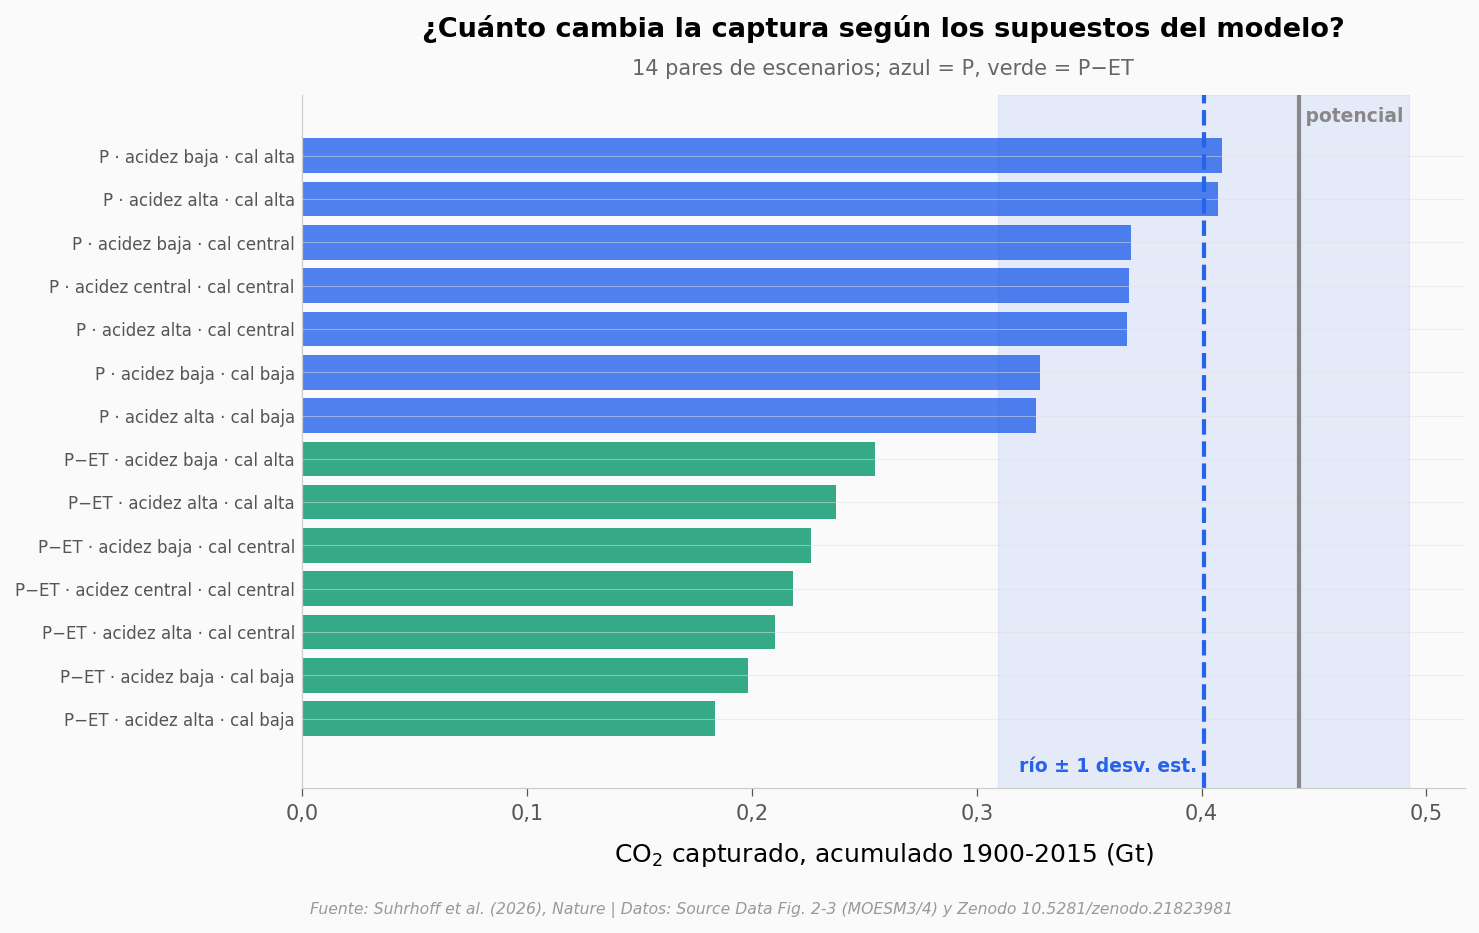

Rango de los 14 pares de escenarios: 0,18–0,41 GtCO₂ = 41–92 % del potencial


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Captura acumulada = emisiones sin cal − emisiones con cal, sumadas hasta ANIO_FINAL,
# comparando cada escenario con cal con el escenario sin cal de su misma acidez.
sub = esc[esc['anio'] <= ANIO_FINAL]
NIVEL = {'best': 'central', '+1sd': 'alta', '-1sd': 'baja'}
filas = []
for col in esc.columns:
    if '|acidez_cal|' not in col:
        continue
    forz, _, acid, cal = col.split('|')
    ref = f'{forz}|solo_acidez|{acid}|sin_cal'
    filas.append({'escenario': f'{forz.replace("PET", "P−ET")} · acidez {NIVEL[acid[5:]]} · cal {NIVEL[cal[4:]]}',
                  'forzamiento': forz, 'cdr_GtCO2': (sub[ref] - sub[col]).sum() / 1000})
tab = pd.DataFrame(filas).sort_values('cdr_GtCO2')

pot_f = cdr.loc[cdr['anio'] == ANIO_FINAL, 'potencial_cdr_GtCO2'].iloc[0]
rio_f = rio.loc[rio['anio'] == ANIO_FINAL, 'cdr_GtCO2'].iloc[0]
rio_sd = rio.loc[rio['anio'] == ANIO_FINAL, 'cdr_sd_GtCO2'].iloc[0]

fig, ax = plt.subplots(figsize=(10, 6))
colores = [COLOR_DATOS if f == 'P' else COLOR_MODELO for f in tab['forzamiento']]
ax.barh(range(len(tab)), tab['cdr_GtCO2'], color=colores, alpha=0.8)
ax.axvspan(rio_f - rio_sd, rio_f + rio_sd, color=COLOR_DATOS, alpha=0.1)
ax.axvline(rio_f, color=COLOR_DATOS, linewidth=2, linestyle='--')
ax.axvline(pot_f, color=COLOR_GRIS, linewidth=2)
ax.text(pot_f, len(tab) - 0.3, ' potencial', color=COLOR_GRIS, fontsize=9, fontweight='bold', va='bottom')
ax.text(rio_f, -1.1, 'río ± 1 desv. est. ', color=COLOR_DATOS, fontsize=9, fontweight='bold', ha='right', va='center')
ax.set_yticks(range(len(tab)))
ax.set_yticklabels(tab['escenario'], fontsize=8)
ax.set_ylim(-1.6, len(tab) + 0.4)
ax.xaxis.set_major_formatter(COMA)
ax.set_xlabel(f'CO$_2$ capturado, acumulado 1900-{ANIO_FINAL} (Gt)')
ax.set_title('¿Cuánto cambia la captura según los supuestos del modelo?', fontsize=13, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '14 pares de escenarios; azul = P, verde = P−ET', transform=ax.transAxes,
        fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/escenarios_modelo.png', dpi=200, bbox_inches='tight')
plt.show()
pr(f'Rango de los {len(tab)} pares de escenarios: {es(tab["cdr_GtCO2"].min())}–{es(tab["cdr_GtCO2"].max())} GtCO₂ '
   f'= {es(100 * tab["cdr_GtCO2"].min() / pot_f, 0)}–{es(100 * tab["cdr_GtCO2"].max() / pot_f, 0)} % del potencial')

---

**Datos:** Source Data de las figuras 2 y 3 del paper (MOESM3 y MOESM4) y el repositorio Zenodo de los
autores (balance de acidez y cal por fuente, bicarbonato del Misisipi procesado a partir de Raymond et al.
2018, y 20 escenarios del modelo SCEPTER). Todas las series son medias o totales de la cuenca, 1900-2015.

**Licencia del paper:** CC BY-NC-ND 4.0

**Repositorio:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab/tree/main/papers/2026-09-23-encalado-agricola-sumidero-carbono)

## Fuentes

**Paper**: [Agricultural liming is a carbon sink in the Mississippi River Basin](https://doi.org/10.1038/s41586-026-11040-2)  
*Nature, 2026-09-23*

**Supplementary Material**: [Source Data Fig. 2 — Agricultural liming is a carbon sink in the Mississippi River Basin (MOESM3)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-11040-2/MediaObjects/41586_2026_11040_MOESM3_ESM.xlsx)  
*Nature, 2026-09-23*

**Supplementary Material**: [Source Data Fig. 3 — Agricultural liming is a carbon sink in the Mississippi River Basin (MOESM4)](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41586-026-11040-2/MediaObjects/41586_2026_11040_MOESM4_ESM.xlsx)  
*Nature, 2026-09-23*

**Datos**: [Data and code associated with "Agricultural liming is a carbon sink in the Mississippi River Basin", Suhrhoff et al. (2026)](https://doi.org/10.5281/zenodo.21823981)  
*Zenodo, 2026-08-06*

**Referencias citadas**: [Figure 2.csv — Mississippi River discharge and bicarbonate flux 1900-2015 (Raymond et al. 2018; copia procesada incluida en s2)](https://doi.org/10.6084/m9.figshare.5753049)

*18 afirmaciones del notebook verificadas contra estas fuentes*